In [2]:
import pandas as pd
import numpy as np
import json
import joblib

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = np.load('../data/processed/y_test.npy')

with open('../data/processed/label_mapping.json') as f:
    label_mapping = json.load(f)

rf_model = joblib.load('../models/rf_model.pkl')

print("X_test shape:", X_test.shape)
print("Model loaded successfully")

X_test shape: (11942, 23)
Model loaded successfully


In [3]:
import shap

print("SHAP version:", shap.__version__)


SHAP version: 0.49.1


In [4]:
explainer = shap.TreeExplainer(rf_model)
print("TreeSHAP explainer created successfully")

TreeSHAP explainer created successfully


In [5]:
X_test_sample = X_test.sample(n=500, random_state=42)

shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated successfully")

SHAP values calculated successfully


In [6]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))
    print("Shape of first class:", shap_values[0].shape)
else:
    print("SHAP values shape:", shap_values.shape)

<class 'numpy.ndarray'>
SHAP values shape: (500, 23, 14)


In [7]:
feature_importance = np.abs(shap_values).mean(axis=(0, 2))

shap_importance = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Mean |SHAP|': feature_importance
})

shap_importance = shap_importance.sort_values(
    by='Mean |SHAP|',
    ascending=False
)

print(shap_importance)

               Feature  Mean |SHAP|
11         min_flowiat     0.013027
10  flowBytesPerSecond     0.012515
4             min_biat     0.011420
14         std_flowiat     0.010310
12         max_flowiat     0.009762
3             min_fiat     0.009691
13        mean_flowiat     0.008801
8            mean_biat     0.008578
1           total_fiat     0.008503
20           mean_idle     0.008198
0             duration     0.007969
2           total_biat     0.007781
7            mean_fiat     0.007651
9    flowPktsPerSecond     0.007305
5             max_fiat     0.006205
6             max_biat     0.005849
21            max_idle     0.005400
16         mean_active     0.005254
17          max_active     0.003303
15          min_active     0.003240
19            min_idle     0.003138
22            std_idle     0.000761
18          std_active     0.000713


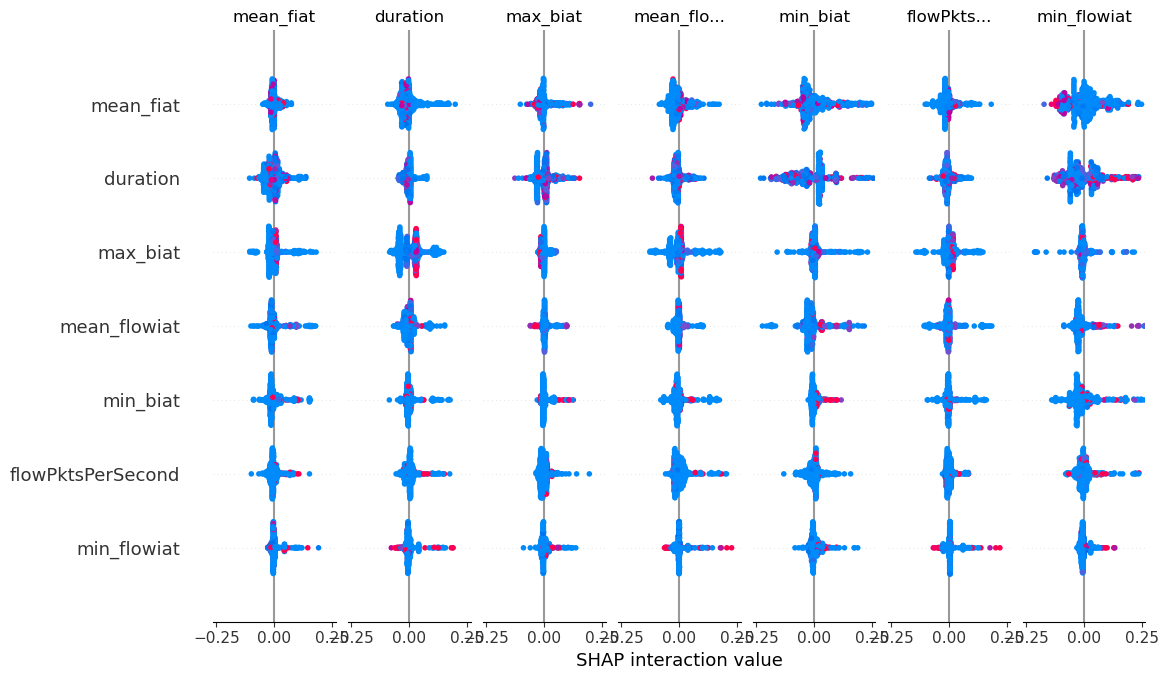

In [8]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=X_test_sample.columns
)

In [9]:
print(label_mapping)

{'BROWSING': 0, 'CHAT': 1, 'FT': 2, 'MAIL': 3, 'P2P': 4, 'STREAMING': 5, 'VOIP': 6, 'VPN-BROWSING': 7, 'VPN-CHAT': 8, 'VPN-FT': 9, 'VPN-MAIL': 10, 'VPN-P2P': 11, 'VPN-STREAMING': 12, 'VPN-VOIP': 13}


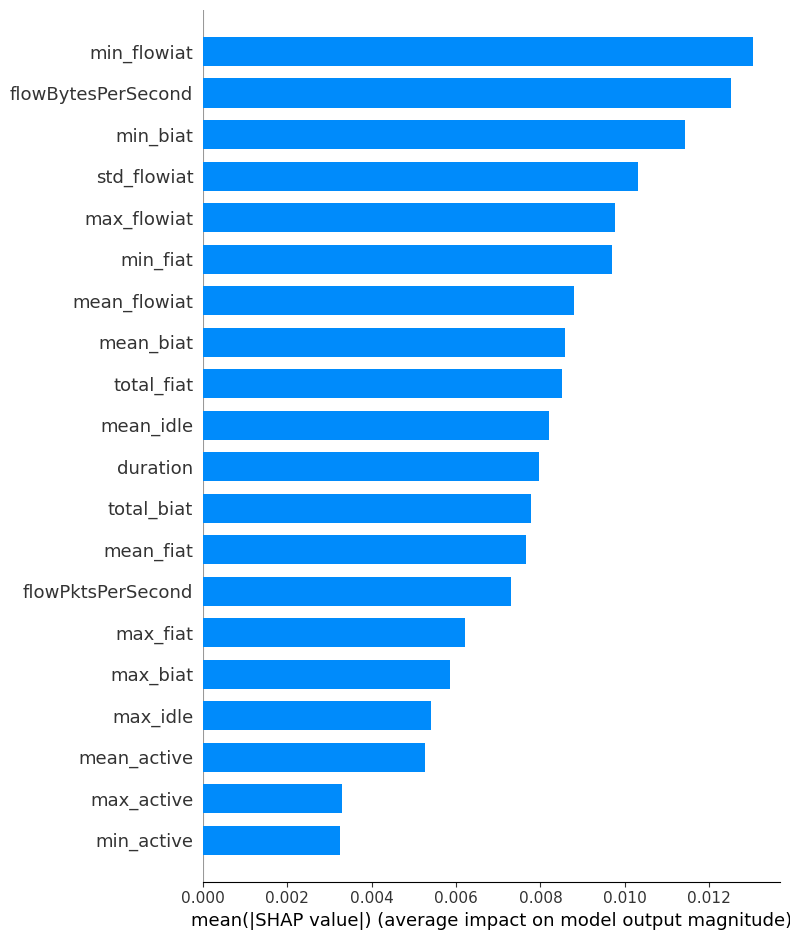

In [10]:
global_shap = np.mean(np.abs(shap_values), axis=2)

shap.summary_plot(
    global_shap,
    X_test_sample,
    feature_names=X_test_sample.columns,
    plot_type="bar"
)

In [11]:
print("FT:", label_mapping["FT"])
print("VPN-CHAT:", label_mapping["VPN-CHAT"])
print("VPN-P2P:", label_mapping["VPN-P2P"])

FT: 2
VPN-CHAT: 8
VPN-P2P: 11


In [13]:
y_pred = rf_model.predict(X_test)

print("Predictions generated successfully")

Predictions generated successfully


In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

classes_to_check = [2, 8, 11]

print("Confusion among FT, VPN-CHAT and VPN-P2P:")
print()

for actual in classes_to_check:
    print(f"Actual class {actual}:")
    for predicted in classes_to_check:
        if actual != predicted:
            print(f"  Predicted as {predicted}: {cm[actual, predicted]}")
    print()

Confusion among FT, VPN-CHAT and VPN-P2P:

Actual class 2:
  Predicted as 8: 9
  Predicted as 11: 137

Actual class 8:
  Predicted as 2: 0
  Predicted as 11: 34

Actual class 11:
  Predicted as 2: 1
  Predicted as 8: 1



In [15]:
# Find FT samples that were incorrectly predicted as VPN-P2P

ft_to_p2p = (y_test == 2) & (y_pred == 11)

print("Number of FT → VPN-P2P errors:", ft_to_p2p.sum())

# Get the positions of these errors
error_positions = np.where(ft_to_p2p)[0]

print("First 10 error positions:")
print(error_positions[:10])

Number of FT → VPN-P2P errors: 137
First 10 error positions:
[  14  104  148  205  249  320  384  616  916 1096]


In [16]:
# Select the first FT → VPN-P2P misclassified flow

idx = error_positions[0]

print("Test-set position:", idx)
print("Actual class:", y_test[idx])
print("Predicted class:", y_pred[idx])

Test-set position: 14
Actual class: 2
Predicted class: 11


In [17]:
# SHAP values for the selected flow
sample_shap = shap_values[idx, :, :]

print("SHAP shape for this flow:", sample_shap.shape)

SHAP shape for this flow: (23, 14)


In [18]:
sample_positions = X_test.index.get_indexer(X_test_sample.index)

sample_error_mask = ft_to_p2p[sample_positions]

sample_error_indices = np.where(sample_error_mask)[0]

print("FT → VPN-P2P errors in SHAP sample:", len(sample_error_indices))
print("First sample index:", sample_error_indices[0])



FT → VPN-P2P errors in SHAP sample: 6
First sample index: 4


In [19]:
sample_idx = sample_error_indices[0]
full_idx = sample_positions[sample_idx]

print("SHAP sample index:", sample_idx)
print("Full test-set position:", full_idx)
print("Actual class:", y_test[full_idx])
print("Predicted class:", y_pred[full_idx])

SHAP sample index: 4
Full test-set position: 3753
Actual class: 2
Predicted class: 11


In [20]:
sample_shap = shap_values[sample_idx, :, 11]

feature_contribution = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'SHAP Value': sample_shap
})

feature_contribution['Abs SHAP'] = np.abs(feature_contribution['SHAP Value'])

feature_contribution = feature_contribution.sort_values(
    by='Abs SHAP',
    ascending=False
)

print(feature_contribution.head(10))

               Feature  SHAP Value  Abs SHAP
10  flowBytesPerSecond    0.042435  0.042435
14         std_flowiat    0.034807  0.034807
9    flowPktsPerSecond    0.030126  0.030126
11         min_flowiat    0.028703  0.028703
7            mean_fiat    0.021778  0.021778
8            mean_biat    0.021631  0.021631
0             duration    0.020221  0.020221
1           total_fiat    0.020091  0.020091
12         max_flowiat    0.020013  0.020013
13        mean_flowiat    0.018780  0.018780


In [21]:
negative_contributions = feature_contribution[
    feature_contribution['SHAP Value'] < 0
].sort_values(by='SHAP Value')

print(negative_contributions)

Empty DataFrame
Columns: [Feature, SHAP Value, Abs SHAP]
Index: []


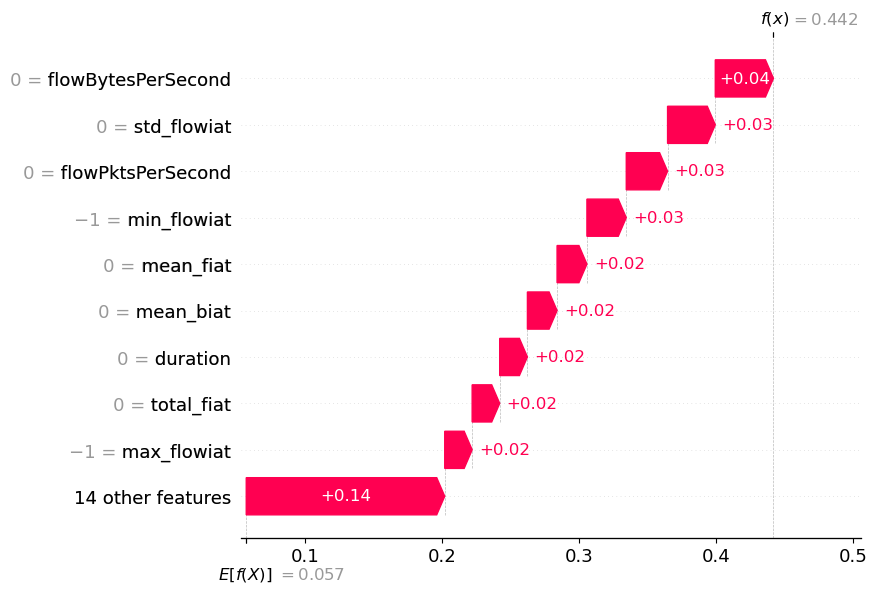

In [22]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx, :, 11],
        base_values=explainer.expected_value[11],
        data=X_test_sample.iloc[sample_idx],
        feature_names=X_test_sample.columns
    ),
    max_display=10
)